In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluación y Selección
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [16]:
# Definimos la ruta de tu archivo local
CSV_PATH = "outputs/processed/sevilla_pixel_data.csv"

# Cargamos el DataFrame
df = pd.read_csv(CSV_PATH)

print(f"✅ Dataset cargado correctamente: {CSV_PATH}")
print(f"Total de píxeles (registros): {len(df)}")
print(f"Variables disponibles: {list(df.columns)}")

# Mostramos las primeras filas para verificar
df.head()

✅ Dataset cargado correctamente: outputs/processed/sevilla_pixel_data.csv
Total de píxeles (registros): 484356
Variables disponibles: ['Longitude', 'Latitude', 'NDVI', 'NDBI', 'Albedo', 'D2W_meters', 'LST_Target', 'D2R_HighCapacity_m', 'D2R_Urban_m', 'Tree_Density_50m', 'Building_Density_100m', 'Avg_Building_Height_100m']


,Longitude,Latitude,NDVI,NDBI,Albedo,D2W_meters,LST_Target,D2R_HighCapacity_m,D2R_Urban_m,Tree_Density_50m,Building_Density_100m,Avg_Building_Height_100m
0,-6.029941,37.449956,0.505166,-0.178238,0.157998,20.000000,40.960874,2743.999249,2776.807410,1,0,0.0
1,-6.029762,37.449956,0.728687,-0.395285,0.181745,20.000000,40.714777,2743.879563,2760.939843,1,0,0.0
2,-6.029582,37.449956,0.763079,-0.424442,0.149877,20.000000,40.714777,2743.851804,2745.072446,1,0,0.0
3,-6.029402,37.449956,0.775685,-0.418584,0.147389,22.360680,40.379811,2743.915975,2729.205220,1,0,0.0
4,-6.029223,37.449956,0.835151,-0.530323,0.201774,28.284271,40.379811,2744.072070,2713.338171,1,0,0.0


In [17]:
# 1. Definimos cuáles son las variables predictoras (Features)
# Excluimos Lat y Lon para que el modelo aprenda de física y urbanismo, no de coordenadas
features = [
    'NDVI', 
    'NDBI', 
    'Albedo',
    'D2W_meters', 
    'D2R_HighCapacity_m',       # Nueva: Distancia a autovías/SE-30
    'D2R_Urban_m',              # Nueva: Distancia a calles urbanas
    'Tree_Density_50m',
    'Building_Density_100m',    # Nueva: Densidad constructiva
    'Avg_Building_Height_100m'  # Nueva: Proxy del Sky View Factor (Sombra/Atrapamiento)
]

target = 'LST_Target'

# Eliminamos cualquier posible valor nulo que se haya colado en el CSV
df_clean = df.dropna(subset=features + [target]).copy()

X = df_clean[features] 
y = df_clean[target]

# 2. Partición 80% Entrenamiento / 20% Test oculto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalamos los datos (Crucial para modelos lineales y redes neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamaño de Entrenamiento: {X_train.shape}")
print(f"Tamaño de Test: {X_test.shape}")

Tamaño de Entrenamiento: (387484, 9)
Tamaño de Test: (96872, 9)


In [18]:
# Suponiendo que las librerías necesarias (XGBRegressor) ya están importadas
print("Entrenando el modelo XGBoost con los mejores hiperparámetros...")

# 1. Instanciar el modelo directamente con los mejores parámetros encontrados
mejor_modelo_final_XGBoost = XGBRegressor(
    random_state=42,
    learning_rate=0.1,
    max_depth=10,
    n_estimators=500,
    num_leaves=31, 
    n_jobs=-1 # Usar todos los núcleos disponibles
)

# 2. Entrenar el modelo
mejor_modelo_final_XGBoost.fit(X_train_scaled, y_train)

print("¡Modelo entrenado con éxito!")

Entrenando el modelo XGBoost con los mejores hiperparámetros...
¡Modelo entrenado con éxito!


--- MÉTRICAS FINALES EN TEST ---
R2 Score: 0.8331
RMSE: 1.6290 °C
MAE: 1.1470 °C


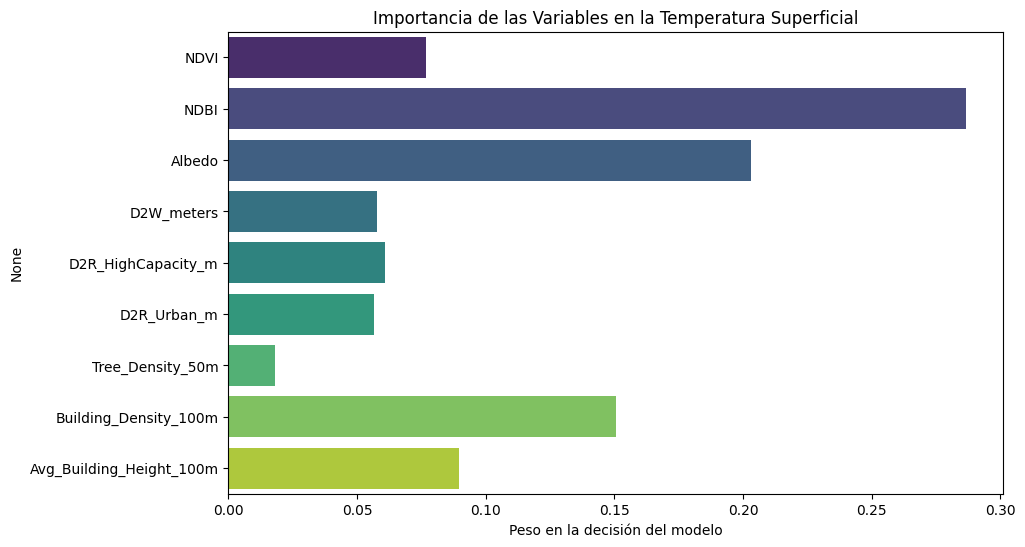

In [19]:
# Hacemos las predicciones sobre el 20% de datos que el modelo nunca ha visto
y_pred = mejor_modelo_final_XGBoost.predict(X_test_scaled)

print("--- MÉTRICAS FINALES EN TEST ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} °C")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} °C")

# Gráfico de Importancia de Variables (Vital para el TFM)
importancias = mejor_modelo_final_XGBoost.feature_importances_
nombres_variables = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=nombres_variables, palette="viridis")
plt.title("Importancia de las Variables en la Temperatura Superficial")
plt.xlabel("Peso en la decisión del modelo")
plt.show()

In [20]:
import joblib
import os

# Creamos una carpeta para guardar los modelos si no existe
os.makedirs("models", exist_ok=True)

# Ruta donde guardaremos el modelo ganador
ruta_modelo = "models/xgboost_sevilla_temperatura_v1.pkl"
ruta_modelo_firebase = "firebase_functions/functions/models/xgboost_sevilla_temperatura_v1.pkl"


# Guardamos el modelo
joblib.dump(mejor_modelo_final_XGBoost, ruta_modelo)
joblib.dump(scaler, "models/xgboost_sevilla_temperatura_v1_scaler.pkl")
print("✅ Escalador guardado correctamente.")

joblib.dump(mejor_modelo_final_XGBoost, ruta_modelo_firebase)
joblib.dump(scaler, "firebase_functions/functions/models/xgboost_sevilla_temperatura_v1_scaler.pkl")
print("✅ Escalador guardado correctamente.")

print(f"✅ ¡Modelo guardado de forma segura en {ruta_modelo}!")

✅ Escalador guardado correctamente.
✅ Escalador guardado correctamente.
✅ ¡Modelo guardado de forma segura en models/xgboost_sevilla_temperatura_v1.pkl!


In [21]:
import time

# Medir XGBoost
inicio = time.time()
xgb_preds = mejor_modelo_final_XGBoost.predict(X_test_scaled)
fin = time.time()
print(f"XGBoost tardó: {fin - inicio:.4f} segundos")


XGBoost tardó: 0.3935 segundos


In [23]:
import numpy as np
import pandas as pd

# 1. Creamos exactamente el mismo dato que le mandaste a Firebase, 
# pero en formato DataFrame para que el scaler no se queje de los nombres
datos_prueba = pd.DataFrame([{
    'NDVI': 0.15,
    'NDBI': 0.25,
    'Albedo': 0.18,
    'D2W_meters': 1200.5,
    'D2R_HighCapacity_m': 350.0,
    'D2R_Urban_m': 15.0,
    'Tree_Density_50m': 3,
    'Building_Density_100m': 45,
    'Avg_Building_Height_100m': 12.0
}])

# 2. Escalamos usando el scaler que guardaste
datos_escalados = scaler.transform(datos_prueba)
print("Array escalado en LOCAL:", datos_escalados[0])

# 3. Predecimos con el modelo XGBoost definitivo
prediccion_local = mejor_modelo_final_XGBoost.predict(datos_escalados)

print(f"Temperatura predicha en Jupyter: {prediccion_local[0]:.2f} °C")

Array escalado en LOCAL: [-0.35264466  1.56082777 -0.54617681  5.16398677 -0.94483914 -0.95213246
  3.50009222  1.88127774  1.09199535]
Temperatura predicha en Jupyter: 41.93 °C
